<a href="https://colab.research.google.com/github/aannddrree/disciplinaIA/blob/main/embeddings_busca_semantica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Embeddings, similaridade e busca semântica

**Objetivos de aprendizagem**

- Explicar o que são vetores e embeddings;
- Calcular similaridade de cosseno;
- Diferenciar busca lexical de busca semântica;
- Criar, em Python, um buscador de documentos semelhantes.

## 1. Ideia central

Computadores não comparam significados diretamente: eles operam com números. Um **embedding** é uma representação numérica (um vetor) de um objeto — por exemplo, palavra, frase, imagem ou documento. O treinamento de um modelo ajusta esses números para que conteúdos com sentidos relacionados fiquem próximos no espaço vetorial.

Exemplo intuitivo: documentos sobre `futebol`, `gol` e `campeonato` tendem a ocupar uma região parecida; documentos sobre `banco`, `empréstimo` e `juros`, outra.

## 2. Vetores

Um vetor é uma lista ordenada de números, como $v=[0{,}8, 0{,}1, 0{,}6]$. Cada posição é uma dimensão.

Nesta primeira demonstração, usaremos apenas duas dimensões interpretáveis: `tecnologia` e `esporte`.

In [ ]:
import numpy as np

# [tecnologia, esporte] — exemplo pedagógico criado manualmente
documentos_2d = {
    'IA no atendimento ao cliente': np.array([0.95, 0.05]),
    'Campeonato de futebol': np.array([0.05, 0.95]),
    'Análise de dados para times': np.array([0.55, 0.70]),
}
documentos_2d

{'IA no atendimento ao cliente': array([0.95, 0.05]),
 'Campeonato de futebol': array([0.05, 0.95]),
 'Análise de dados para times': array([0.55, 0.7 ])}

No plano, cada documento vira um ponto. A distância/direção entre os pontos pode servir para estimar relação. Em aplicações reais, o modelo aprende essa representação a partir de muitos exemplos de linguagem.

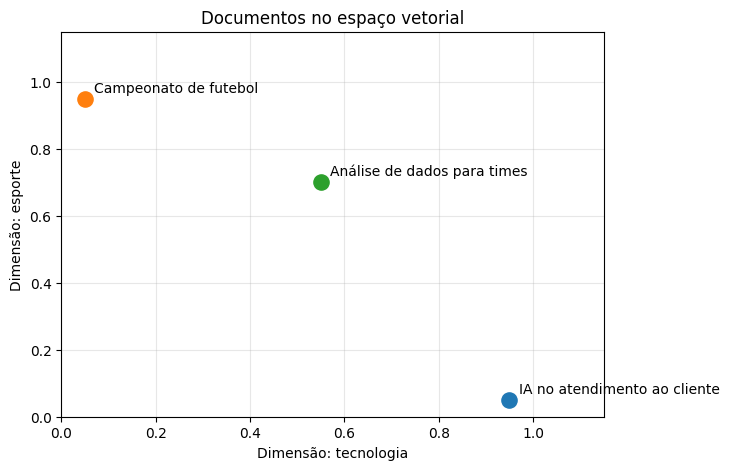

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
for texto, vetor in documentos_2d.items():
    plt.scatter(*vetor, s=120)
    plt.annotate(texto, vetor + 0.02)
plt.xlim(0, 1.15); plt.ylim(0, 1.15)
plt.xlabel('Dimensão: tecnologia'); plt.ylabel('Dimensão: esporte')
plt.grid(alpha=0.3); plt.title('Documentos no espaço vetorial');
plt.show()

## 3. Similaridade: cosseno

A medida mais usada com embeddings é a **similaridade de cosseno**. Ela compara a direção de dois vetores, e não o seu tamanho:

$$\operatorname{cos}(a,b)=\frac{a\cdot b}{\|a\|\|b\|}$$

O resultado varia em geral de -1 a 1: `1` significa mesma direção (muito similares), `0` significa sem relação direcional, e `-1` direções opostas. Em muitos embeddings de texto, resultados úteis ficam entre 0 e 1.

In [ ]:
def similaridade_cosseno(a, b):
    """Retorna a similaridade de cosseno entre dois vetores."""
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

ia = documentos_2d['IA no atendimento ao cliente']
futebol = documentos_2d['Campeonato de futebol']
dados_times = documentos_2d['Análise de dados para times']

print(f'IA × futebol: {similaridade_cosseno(ia, futebol):.3f}')
print(f'IA × dados para times: {similaridade_cosseno(ia, dados_times):.3f}')
print(f'futebol × dados para times: {similaridade_cosseno(futebol, dados_times):.3f}')

IA × futebol: 0.105
IA × dados para times: 0.658
futebol × dados para times: 0.818


## 4. Busca lexical × busca semântica

A busca **lexical** localiza termos literais. Por isso, uma consulta por `automóvel` pode não encontrar um texto que usa somente `carro`. A busca **semântica** transforma consulta e documentos em embeddings e retorna os vetores mais próximos. Assim, pode recuperar sinônimos, paráfrases e contexto relacionado.

Ela não é mágica: pode errar ambiguidades, refletir vieses dos dados de treinamento e recuperar textos apenas superficialmente relacionados. Avaliação humana e métricas são importantes.

## 5. Conjunto de documentos da prática

Vamos criar uma pequena base. O objetivo é pesquisar algo como *“como reduzir fraudes em pagamentos?”* e encontrar o texto sobre transações suspeitas, mesmo que as palavras não sejam exatamente as mesmas.

In [ ]:
documentos = [
    'O banco identificou transações suspeitas com aprendizado de máquina.',
    'O time de desenvolvimento lançou uma aplicação móvel para clientes.',
    'Técnicas de inteligência artificial ajudam a detectar fraude em pagamentos.',
    'A equipe venceu o torneio após marcar três gols na final.',
    'A empresa adotou criptografia para proteger dados pessoais dos usuários.',
    'Modelos preditivos avaliam risco de crédito em solicitações de empréstimo.',
    'O curso ensina programação em Python e análise de dados.'
]

for i, documento in enumerate(documentos):
    print(f'{i}: {documento}')

0: O banco identificou transações suspeitas com aprendizado de máquina.
1: O time de desenvolvimento lançou uma aplicação móvel para clientes.
2: Técnicas de inteligência artificial ajudam a detectar fraude em pagamentos.
3: A equipe venceu o torneio após marcar três gols na final.
4: A empresa adotou criptografia para proteger dados pessoais dos usuários.
5: Modelos preditivos avaliam risco de crédito em solicitações de empréstimo.
6: O curso ensina programação em Python e análise de dados.


## 6. Linha de base: representação TF-IDF - (Term Frequency-Inverse Document Frequency, ou Frequência do Termo–Inverso da Frequência nos Documentos)

TF-IDF transforma texto em vetores com base na importância das palavras. É uma ótima linha de base, rápida e explicável, mas ainda depende fortemente da sobreposição de termos. Não é um embedding contextual moderno.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vetorizador_tfidf = TfidfVectorizer(stop_words='english')  # mantemos palavras em PT para simplificar
matriz_tfidf = vetorizador_tfidf.fit_transform(documentos)
print('Formato da matriz:', matriz_tfidf.shape)
print('Cada linha é um documento; cada coluna é um termo do vocabulário.')

Formato da matriz: (7, 52)
Cada linha é um documento; cada coluna é um termo do vocabulário.


In [ ]:
def buscar_tfidf(consulta, k=3):
    vetor_consulta = vetorizador_tfidf.transform([consulta])
    escores = cosine_similarity(vetor_consulta, matriz_tfidf).flatten()
    ranking = escores.argsort()[::-1][:k]
    return [(int(i), documentos[i], float(escores[i])) for i in ranking]

consulta = 'como detectar fraude em pagamentos?'
for indice, texto, escore in buscar_tfidf(consulta):
    print(f'[{indice}] {escore:.3f} — {texto}')

[2] 0.683 — Técnicas de inteligência artificial ajudam a detectar fraude em pagamentos.
[6] 0.108 — O curso ensina programação em Python e análise de dados.
[5] 0.098 — Modelos preditivos avaliam risco de crédito em solicitações de empréstimo.


Observe os escores. TF-IDF costuma encontrar bem a palavra `fraude`, mas pode deixar de recuperar um texto relacionado que fale em `transações suspeitas`. Agora usaremos embeddings de sentenças multilíngues.

> Na primeira execução, o modelo é baixado. Execute a próxima célula se o ambiente ainda não tiver a biblioteca.

In [ ]:
# Descomente e execute apenas se necessário:
# %pip install -q sentence-transformers

## 7. Busca semântica com embeddings modernos

`paraphrase-multilingual-MiniLM-L12-v2` é um modelo que representa sentenças de vários idiomas, incluindo português, em vetores de 384 dimensões. O mesmo codificador deve ser aplicado aos documentos e à consulta.

In [ ]:
from sentence_transformers import SentenceTransformer

modelo = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
# normalize_embeddings=True permite usar produto interno como similaridade de cosseno
embeddings_documentos = modelo.encode(documentos, normalize_embeddings=True)
print('Formato dos embeddings:', embeddings_documentos.shape)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Formato dos embeddings: (7, 384)


In [ ]:
def buscar_semantica(consulta, k=3):
    embedding_consulta = modelo.encode([consulta], normalize_embeddings=True)
    # Como os vetores estão normalizados, produto interno = cosseno
    escores = (embedding_consulta @ embeddings_documentos.T).flatten()
    ranking = escores.argsort()[::-1][:k]
    return [(int(i), documentos[i], float(escores[i])) for i in ranking]

consulta = 'como reduzir fraudes em pagamentos?'
for indice, texto, escore in buscar_semantica(consulta):
    print(f'[{indice}] {escore:.3f} — {texto}')

[2] 0.609 — Técnicas de inteligência artificial ajudam a detectar fraude em pagamentos.
[0] 0.349 — O banco identificou transações suspeitas com aprendizado de máquina.
[5] 0.279 — Modelos preditivos avaliam risco de crédito em solicitações de empréstimo.


## 8. Interpretando o algoritmo

O fluxo da busca semântica é simples:

1. Codificar todos os documentos uma vez e guardar seus vetores.
2. Codificar a consulta do usuário com o mesmo modelo.
3. Calcular a similaridade da consulta com cada documento.
4. Ordenar os escores em ordem decrescente e devolver os primeiros `k`.

Em uma base grande, o passo 3 é acelerado por índices vetoriais como FAISS, Chroma, pgvector ou serviços de banco vetorial.

## 9. Exercícios propostos

1. Acrescente cinco documentos sobre saúde, educação ou comércio eletrônico e repita a busca.
2. Teste as consultas `proteção de informações dos clientes` e `análise para concessão de crédito`. Compare TF-IDF e embeddings.
3. Altere `k` para 5. Em que ponto os resultados deixam de ser relevantes?
4. Crie uma função que retorne somente itens com escore maior que um limiar, por exemplo `0.45`. Discuta por que um limiar fixo nem sempre funciona.
5. Desafio: crie uma interface simples com Streamlit ou Gradio para receber a consulta e mostrar os resultados.

## 10. Síntese

- **Vetores** representam objetos como números.
- **Embeddings** são vetores aprendidos para preservar relações relevantes.
- **Similaridade de cosseno** mede o alinhamento entre vetores.
- **Busca semântica** encontra conteúdos relacionados mesmo quando a redação é diferente.
- Para uso real, avalie qualidade com consultas representativas, monitore vieses e combine busca semântica com filtros, metadados e, quando útil, busca lexical.